# Lecture 9 — Linear Independence, Spanning, Basis, and Dimension
Instructor: Gilbert Strang

In this lecture, we shift from solving systems to understanding the structure of vector spaces.

Instead of focusing on Ax = b, we ask:

- When are vectors redundant?
- How can a set of vectors generate a space?
- What is the minimum set needed to describe that space?

---

We will introduce four key ideas:

- Linear independence
- Spanning
- Basis
- Dimension

These concepts describe how vectors relate to each other and how they build spaces.

## Section 1 — Linear Independence

We begin with a simple question:

Do these vectors add new directions, or are some of them redundant?

If one vector can be written as a combination of others, it does not add anything new.

Such vectors are called dependent.

If no vector can be built from the others, the set is independent.

### Definition

Vectors v1, v2, ..., vn are linearly independent if:

c1*v1 + c2*v2 + ... + cn*vn = 0

only when all coefficients are zero:

c1 = c2 = ... = cn = 0

---

If a non-zero combination gives the zero vector, the vectors are dependent.

In [13]:
import random

from sympy import Matrix

import numpy as np

v1 = np.array([1, 2])
v2 = np.array([2, 4])

zero = 2 * v1 - v2
print("Zero vector: ")
display(Matrix(zero))

Zero vector: 


Matrix([
[0],
[0]])

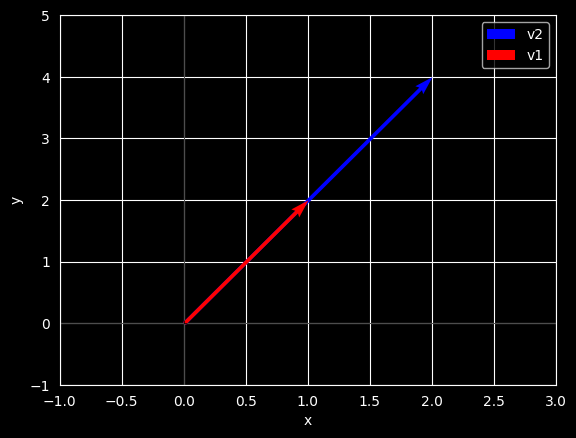

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.quiver(v2[0], v2[1], color="blue", angles='xy', scale_units='xy', scale=1, label="v2")
ax.quiver(v1[0], v1[1], color="red", angles='xy', scale_units='xy', scale=1, label="v1")

ax.axhline(0, color='black',linewidth=0.5)
ax.axvline(0, color='black',linewidth=0.5)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 5)
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

### Interpretation

Here, v2 is a multiple of v1.

Both vectors lie on the same line, so one does not introduce a new direction.

This is linear dependence.

In [31]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])
for _ in range(5):
    c1, c2 = random.random(), random.random()
    zero = c1 * v1 + c2 * v2
    print("Result vector: ")
    display(Matrix(zero))

zero = 0 * v1 + 0 * v2
print("Zero vector: ")
display(Matrix(zero))

Result vector: 


Matrix([
[ 0.11949402380128],
[0.251118063343997]])

Result vector: 


Matrix([
[0.856631511393372],
[0.216424359263907]])

Result vector: 


...

Matrix([
[0.465632080999561],
[0.167128833831198]])

Result vector: 


Matrix([
[ 0.55770721559783],
[0.547744976132957]])

Zero vector: 


Matrix([
[0],
[0]])

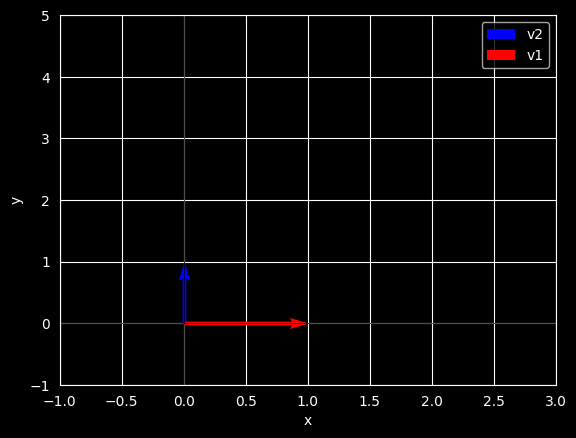

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.quiver(v2[0], v2[1], color="blue", angles='xy', scale_units='xy', scale=1, label="v2")
ax.quiver(v1[0], v1[1], color="red", angles='xy', scale_units='xy', scale=1, label="v1")

ax.axhline(0, color='black',linewidth=0.5)
ax.axvline(0, color='black',linewidth=0.5)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 5)
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()

### Interpretation

These vectors point in different directions.

Neither can be formed from the other.

They are linearly independent.

### Connection to Matrices

If we place the vectors as columns of a matrix A:

A = [v1 v2 ... vn]

then the condition becomes:

A c = 0

---

- If the only solution is c = 0 → vectors are independent
- If there exists a non-zero solution → vectors are dependent

So independence is equivalent to:

The null space of A contains only the zero vector

## Section 2 — More Unknowns than Equations

Consider a matrix A with:

m rows and n columns, where m < n

This means:

- Fewer equations than variables

We want to understand what this implies for independence.

### Key Idea

When solving:

A x = 0

having more variables than equations leads to free variables.

Free variables allow non-zero solutions.

In [33]:
A_small = np.array([
    [1, 2, 3],
    [4, 5, 6]
], dtype=float)

print("A small: ")
Matrix(A_small)

A small: 


Matrix([
[1.0, 2.0, 3.0],
[4.0, 5.0, 6.0]])

### Interpretation

Because there are more variables than equations:

- At least one variable is free
- There exists a non-zero solution to Ax = 0

---

This means:

The null space is not just the zero vector

### Conclusion

If m < n:

- There are free variables
- A x = 0 has non-zero solutions
- The columns of A are linearly dependent

## Section 3 — Spanning a Space

A set of vectors defines a space through all possible combinations of them.

This leads to the idea of spanning.

A set of vectors spans a space if every vector in that space can be written as a combination of them.

### Linear Combinations

Given vectors v1, v2, ..., vn:

Any vector of the form:

c1*v1 + c2*v2 + ... + cn*vn

is called a linear combination of these vectors.

---

The set of all such combinations forms a space.

### Connection to Ax

If we place the vectors as columns of a matrix A:

A = [v1 v2 ... vn]

then:

Ax = x1*v1 + x2*v2 + ... + xn*vn

---

So:

The column space of A is exactly the set of all linear combinations of its columns.

### Visualizing Spanning

We explore how vectors generate spaces:

- One vector generates a line
- Two independent vectors generate a plane

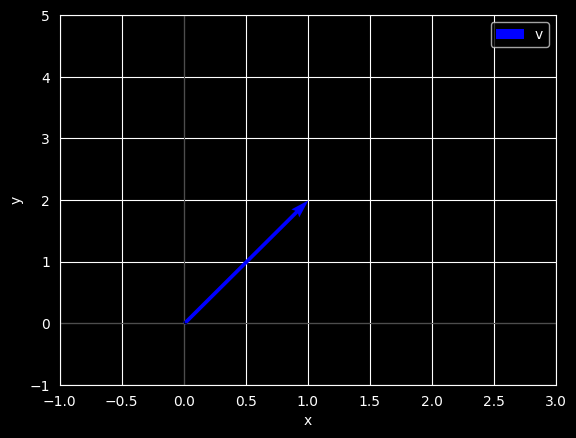

In [34]:
v = np.array([1, 2])
t = np.linspace(-2, 2, 50)
points = t * v.reshape(-1, 1)

fig, ax = plt.subplots()

ax.quiver(v[0], v[1], color="blue", angles='xy', scale_units='xy', scale=1, label="v")

ax.axhline(0, color='black',linewidth=0.5)
ax.axvline(0, color='black',linewidth=0.5)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 5)
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()


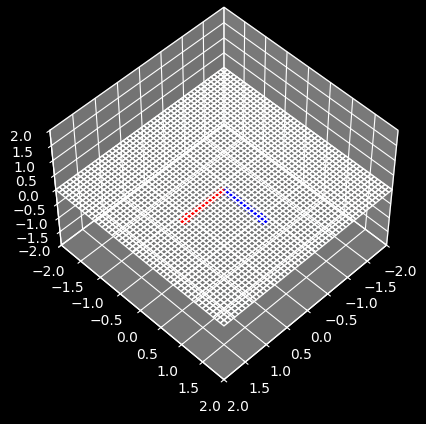

In [62]:
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
s, t = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
plane = s[..., np.newaxis] * v1 + t[..., np.newaxis] * v2
X = plane[..., 0]
Y = plane[..., 1]
Z = plane[..., 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0,0,0,v2[0], v2[1], v2[2], color="blue", label="v2", linewidth=5, arrow_length_ratio=0.2)
ax.quiver(0,0,0,v1[0], v1[1], v1[2], color="red", label="v1", linewidth=5, arrow_length_ratio=0.2)

ax.plot_surface(X, Y, Z, alpha=0.005)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(-2, 2)
ax.view_init(elev=50, azim=45)
plt.show()

### Observation

- A single vector generates a line
- Two independent vectors generate a plane

Spanning describes how vectors build a space through combinations.

### Interpretation

Spanning answers the question:

Do these vectors cover the entire space?

- If yes → they span the space
- If not → they only generate a smaller subspace

## Section 4 — Basis

We now combine two key ideas:

- Linear independence (no redundancy)
- Spanning (full coverage)

A set of vectors that satisfies both is called a basis.

### Definition

A basis for a space is a set of vectors that:

1. Are linearly independent
2. Span the space

### Interpretation

A basis is:

- Minimal → no vector is unnecessary (independence)
- Complete → no direction is missing (spanning)

It is the smallest set of vectors that fully describes the space.

### Visualizing a Basis

In a plane:

- Two independent vectors form a basis
- Adding a third vector creates dependence

In space:

- Three independent vectors are needed to span R^3

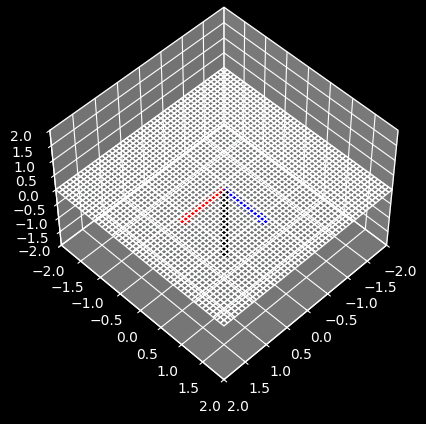

In [61]:
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([1, 1, 0])
s, t = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
plane = s[..., np.newaxis] * v1 + t[..., np.newaxis] * v2
X = plane[..., 0]
Y = plane[..., 1]
Z = plane[..., 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0,0,0,v2[0], v2[1], v2[2], color="blue", label="v2", linewidth=5, arrow_length_ratio=0.2)
ax.quiver(0,0,0,v1[0], v1[1], v1[2], color="red", label="v1", linewidth=5, arrow_length_ratio=0.2)
ax.quiver(0,0,0,v3[0], v3[1], v3[2], color="black", label="v1", linewidth=5, arrow_length_ratio=0.2)

ax.plot_surface(X, Y, Z, alpha=0.005)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(-2, 2)
ax.view_init(elev=50, azim=45)
plt.show()

### Observation

- Independent vectors build the space
- Extra vectors do not add new directions

This shows why a basis must be both independent and spanning.

### Important Result

If a space has dimension d:

- Any set of d independent vectors automatically forms a basis
- Any set of d vectors that spans the space is also a basis

---

This means:

Once we have the correct number of independent vectors, we already have a basis.

### Example — Standard Basis of R^3

The vectors:

- [1, 0, 0]

- [0, 1, 0]

- [0, 0, 1]

are independent and span R^3.

So they form a basis.

### Example — Alternative Basis

Consider:

- [1, 1, 2]

- [2, 2, 5]

- [3, 3, 7]

These vectors are also independent and span R^3.

So they form another valid basis.

---

Different bases can describe the same space.

In [73]:
v1 = np.array([1, 1, 2])
v2 = np.array([2, 2, 5])
v3 = np.array([3, 3, 7])

A_test = np.column_stack((v1, v2, v3))
print("A test: ")
display(Matrix(A_test))
print("Rank: ", np.linalg.matrix_rank(A_test))

A test: 


Matrix([
[1, 2, 3],
[1, 2, 3],
[2, 5, 7]])

Rank:  2


In [74]:
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([0, 0, 1])

A_test = np.column_stack((v1, v2, v3))
print("A test: ")
display(Matrix(A_test))
print("Rank: ", np.linalg.matrix_rank(A_test))


A test: 


Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

Rank:  3


### Interpretation

A space can have many different bases.

What matters is:

- independence
- spanning

Not the specific vectors themselves.

## Section 5 — Dimension

We have seen that a basis is the minimal set of vectors that describes a space.

A natural question is:

How many vectors are needed?

### Definition

The number of vectors in any basis of a space is called the dimension of that space.

---

Every basis for the same space has the same number of vectors.

### Examples

- A line → dimension = 1
- A plane → dimension = 2
- R^3 → dimension = 3

---

The dimension tells us how many independent directions the space has.

### Observation

Each additional independent vector adds a new direction.

The number of independent directions defines the dimension.

### Connection to Basis

Since a basis is:

- independent
- spanning

The number of basis vectors is exactly the dimension of the space.

### Connection to Rank

For a matrix A:

- The number of pivot columns = rank(A)

So:

dimension of C(A) = rank(A)

## Section 6 — Basis of the Column Space C(A)

We now apply the previous concepts to a specific matrix.

The goal is to find a basis for the column space of A.

---

The column space consists of all linear combinations of the columns of A.

### Matrix A

We consider the matrix:

A =
[
- [1, 2, 3, 1]
- [1, 1, 2, 1]
- [1, 2, 3, 1]

]

We want to understand:

- which columns are independent
- which columns form a basis

In [75]:
A = np.array([
    [1, 2, 3, 1],
    [1, 1, 2, 1],
    [1, 2, 3, 1]
])

print("A: ")
Matrix(A)

A: 


Matrix([
[1, 2, 3, 1],
[1, 1, 2, 1],
[1, 2, 3, 1]])

### Strategy

To find a basis for the column space:

1. Perform elimination
2. Identify pivot columns
3. Take those columns from the original matrix A

In [85]:
U = A.copy()

U[2] = U[0] - U[2]
print("\nAfter R2 <- R2 - R1:")
display(Matrix(U))

U[1] = U[1] - U[0]
print("\nAfter R1 <- R1 - R0:")
display(Matrix(U))

U[1] = -U[1]
print("\nAfter R2 <- -R2:")
Matrix(U)


After R2 <- R2 - R1:


Matrix([
[1, 2, 3, 1],
[1, 1, 2, 1],
[0, 0, 0, 0]])


After R1 <- R1 - R0:


Matrix([
[1,  2,  3, 1],
[0, -1, -1, 0],
[0,  0,  0, 0]])


After R2 <- -R2:


Matrix([
[1, 2, 3, 1],
[0, 1, 1, 0],
[0, 0, 0, 0]])

### Pivot Columns

From the echelon form, we identify the pivot columns.

These columns correspond to independent directions.

In [88]:
pivot_indices = [0, 1]
basis_cols = U[:, pivot_indices]
print("Basis columns: ")
Matrix(basis_cols)

Basis columns: 


Matrix([
[1, 2],
[0, 1],
[0, 0]])

### Basis for Column Space

The pivot columns form a basis for the column space of A.

The number of these columns is the rank.

So:

dimension of C(A) = rank(A)

### Interpretation

- These columns span the column space
- No column in this set is redundant
- All other columns can be written as combinations of them

### Visualizing the Column Space

The basis vectors define the directions of the column space.

We can visualize these vectors to understand the space they span.

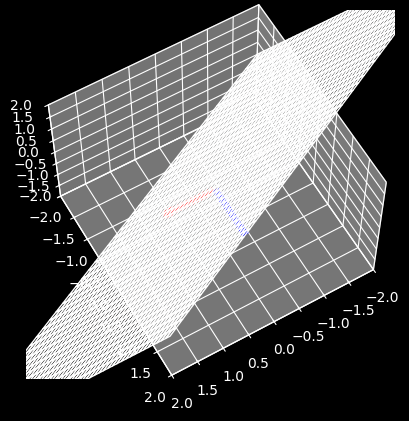

In [95]:
s, t = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(-2, 2, 50))
plane = s[..., np.newaxis] * basis_cols[:, 0] + t[..., np.newaxis] * basis_cols[:, 1]
X = plane[..., 0]
Y = plane[..., 1]
Z = plane[..., 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(0,0,0,v2[0], v2[1], v2[2], color="blue", label="v2", linewidth=5, arrow_length_ratio=0.2)
ax.quiver(0,0,0,v1[0], v1[1], v1[2], color="red", label="v1", linewidth=5, arrow_length_ratio=0.2)


ax.plot_surface(X, Y, Z, alpha=0.005)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(-2, 2)
ax.view_init(elev=60, azim=60)
plt.show()

### Observation

The basis vectors span a plane in R^3.

This confirms that:

- The column space has dimension 2
- All columns lie in this plane

## Section 7 — Basis of the Null Space N(A)

We now study the null space of A.

The null space consists of all solutions to:

A x = 0

---

Our goal is to find a basis for this space.

### Strategy

To find a basis for the null space:

1. Solve A x = 0
2. Identify free variables
3. Express the solution in terms of free variables

Each free variable produces one special solution.

These special solutions form a basis for the null space.

In [105]:
from sympy import symbols

x1, x2, x3, x4 = symbols('x1, x2, x3, x4')
print("Null space equations:")
print(x1 + 2*x2 + 3*x3 + x4, " = 0")
print(x2 + x3, " = 0")
print("x2 = ", -x3)
print("x1 = ", -(-2*x3 + 3*x3 + x4))

Null space equations:
x1 + 2*x2 + 3*x3 + x4  = 0
x2 + x3  = 0
x2 =  -x3
x1 =  -x3 - x4


### Free Variables

From elimination:

- Pivot variables are determined by the system
- Free variables can take any value

Each free variable introduces a direction in the null space.

In [109]:
x3 = 0
x4 = 1
x2 = -x3
x1 = -(-2*x3 + 3*x3 + x4)

print("x1 = ", x1)
print("x2 = ", x2)
print("x3 = ", x3)
print("x4 = ", x4)

print("x1 + 2*x2 + 3*x3 + x4 = ", x1 + 2*x2 + 3*x3 + x4)
print("x2 + x3 = ", x2 + x3)

print("Validation: ")
print("U @ x = 0: ", U @ np.array([x1, x2, x3, x4]))

x1 =  -1
x2 =  0
x3 =  0
x4 =  1
x1 + 2*x2 + 3*x3 + x4 =  0
x2 + x3 =  0
Validation: 
U @ x = 0:  [0 0 0]


In [110]:
x3 = 1
x4 = 0
x2 = -x3
x1 = -(-2*x3 + 3*x3 + x4)

print("x1 = ", x1)
print("x2 = ", x2)
print("x3 = ", x3)
print("x4 = ", x4)

print("x1 + 2*x2 + 3*x3 + x4 = ", x1 + 2*x2 + 3*x3 + x4)
print("x2 + x3 = ", x2 + x3)

print("Validation: ")
print("U @ x = 0: ", U @ np.array([x1, x2, x3, x4]))

x1 =  -1
x2 =  -1
x3 =  1
x4 =  0
x1 + 2*x2 + 3*x3 + x4 =  0
x2 + x3 =  0
Validation: 
U @ x = 0:  [0 0 0]


### Basis for the Null Space

The special solutions form a basis for N(A).

Each vector represents a direction where A maps to zero.

### Dimension of the Null Space

The number of free variables equals:

dimension of N(A)

---

If A has n columns and rank r:

dim N(A) = n - r

### Interpretation

The null space contains all directions that do not change the output Ax.

These directions represent the freedom in the system.

## Conclusion — Independence, Spanning, Basis, and Dimension

In this lecture, we studied how vectors build and describe spaces.

---

### 1. Linear Independence

A set of vectors is independent if:

- no vector can be written as a combination of others
- the only solution to A x = 0 is x = 0

Independence removes redundancy.

---

### 2. Spanning

A set of vectors spans a space if:

- all vectors in the space can be written as combinations of them

Spanning ensures full coverage of the space.

---

### 3. Basis

A basis is a set of vectors that:

- is independent
- spans the space

It is the minimal complete description of a space.

---

### 4. Dimension

The dimension of a space is:

- the number of vectors in any basis

It represents the number of independent directions.

---

### 5. Structure of a Matrix A

For a matrix A:

- Pivot columns form a basis for the column space C(A)
- Special solutions form a basis for the null space N(A)

---

### 6. Key Relationships

dim C(A) = rank(A)
dim N(A) = n - rank(A)

---

### Final Insight

A matrix organizes space in two ways:

- Its columns generate a space (column space)
- Its null space describes directions that do not affect the output

Understanding independence, spanning, basis, and dimension reveals the full structure of these spaces.